In [1]:
import os
from pathlib import Path
import numpy as np
import torch
import torch.nn.functional as F
from PIL import Image
from tqdm.auto import tqdm
from transformers import AutoProcessor, AutoModel

In [2]:
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(device)

mps


In [3]:
os.environ["HF_HOME"] = "models"
MODEL_NAME = "patrickjohncyh/fashion-clip"
processor = AutoProcessor.from_pretrained(MODEL_NAME)
model = AutoModel.from_pretrained(MODEL_NAME).to(device)
model.eval()

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

CLIPModel(
  (text_model): CLIPTextModel(
    (embeddings): CLIPTextEmbeddings(
      (token_embedding): Embedding(49408, 512)
      (position_embedding): Embedding(77, 512)
    )
    (encoder): CLIPEncoder(
      (layers): ModuleList(
        (0-11): 12 x CLIPEncoderLayer(
          (self_attn): CLIPAttention(
            (k_proj): Linear(in_features=512, out_features=512, bias=True)
            (v_proj): Linear(in_features=512, out_features=512, bias=True)
            (q_proj): Linear(in_features=512, out_features=512, bias=True)
            (out_proj): Linear(in_features=512, out_features=512, bias=True)
          )
          (layer_norm1): LayerNorm((512,), eps=1e-05, elementwise_affine=True, bias=True)
          (mlp): CLIPMLP(
            (activation_fn): QuickGELUActivation()
            (fc1): Linear(in_features=512, out_features=2048, bias=True)
            (fc2): Linear(in_features=2048, out_features=512, bias=True)
          )
          (layer_norm2): LayerNorm((512,), eps=1

In [4]:
dataset_dir = Path("dataset")
EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

image_paths = sorted([
    p for p in dataset_dir.iterdir()
    if p.suffix.lower() in EXTENSIONS
])
print(f"Found {len(image_paths)} images")

Found 3200 images


In [5]:
from torch.utils.data import Dataset

class ImageDataset(Dataset):
    def __init__(self, image_paths):
        self.image_paths = image_paths
    def __len__(self):
        return len(self.image_paths)
    def __getitem__(self, idx):
        image = Image.open(self.image_paths[idx]).convert("RGB")
        return image, str(self.image_paths[idx])

In [6]:
from torch.utils.data import DataLoader

dataset = ImageDataset(image_paths)

def collate_fn(batch):
    images, paths = zip(*batch)
    inputs = processor(
        images=list(images),
        return_tensors="pt"
    )
    return inputs, paths

loader = DataLoader(
    dataset,
    batch_size=32,
    shuffle=False,
    num_workers=0,
    collate_fn=collate_fn
)

In [7]:
all_embeddings = []
all_paths = []

with torch.no_grad():
    for inputs, paths in tqdm(loader):
        inputs = {k: v.to(device) for k, v in inputs.items()}
        outputs = model.get_image_features(**inputs)
        if hasattr(outputs, "pooler_output") and outputs.pooler_output is not None:
            embeddings = outputs.pooler_output
        elif hasattr(outputs, "image_embeds") and outputs.image_embeds is not None:
            embeddings = outputs.image_embeds
        elif hasattr(outputs, "text_embeds") and outputs.text_embeds is not None:
            embeddings = outputs.text_embeds
        elif isinstance(outputs, (tuple, list)):
            embeddings = outputs[0]
        else:
            embeddings = outputs
        embeddings = F.normalize(embeddings, dim=-1)
        all_embeddings.append(embeddings.cpu())
        all_paths.extend(paths)

  0%|          | 0/100 [00:00<?, ?it/s]

In [8]:
image_embeddings = torch.cat(all_embeddings)
print(image_embeddings.shape)

torch.Size([3200, 512])


In [9]:
norms = torch.norm(image_embeddings, dim=1)

print(norms.min())
print(norms.max())
print(norms.mean())

tensor(1.0000)
tensor(1.0000)
tensor(1.)


In [10]:
import hnswlib
import numpy as np

embeddings = image_embeddings.cpu().numpy().astype(np.float32)

dimension = embeddings.shape[1]
num_elements = embeddings.shape[0]

index = hnswlib.Index(
    space="cosine",
    dim=dimension
)

index.init_index(
    max_elements=num_elements,
    ef_construction=200,
    M=16
)

index.add_items(
    embeddings,
    np.arange(num_elements)
)

index.set_ef(50)

print(f"Indexed {num_elements} images.")

Indexed 3200 images.


In [11]:
index.save_index("siglip2_hnsw.bin")

In [12]:
index = hnswlib.Index(space="cosine", dim=512)
index.load_index("siglip2_hnsw.bin")

In [13]:
@torch.no_grad()
def encode_text(text):
    inputs = processor(
        text=[text],
        padding=True,
        return_tensors="pt"
    )

    inputs = {k: v.to(device) for k, v in inputs.items()}
    embedding = model.get_text_features(**inputs)
    if hasattr(embedding, "pooler_output") and embedding.pooler_output is not None:
        embedding = embedding.pooler_output
    elif hasattr(embedding, "text_embeds") and embedding.text_embeds is not None:
        embedding = embedding.text_embeds
    elif hasattr(embedding, "image_embeds") and embedding.image_embeds is not None:
        embedding = embedding.image_embeds
    elif isinstance(embedding, (tuple, list)):
        embedding = embedding[0]
    embedding = F.normalize(embedding, dim=-1)
    
    return embedding.cpu().numpy().astype(np.float32)

In [14]:
query_embedding = encode_text("red dress")
query_embedding.shape

(1, 512)

In [15]:
def retrieve(query, k=10):
    query_embedding = encode_text(query).astype(np.float32)
    indices, distances = index.knn_query(
        query_embedding,
        k=k
    )

    results = []
    for idx, dist in zip(indices[0], distances[0]):

        results.append({
            "path": all_paths[idx],
            "score": float(1 - dist)  
        })

    return results

In [16]:
import matplotlib.pyplot as plt

def show_results(results):
    n = len(results)
    fig, axes = plt.subplots(1, n, figsize=(4*n, 4))
    if n == 1:
        axes = [axes]
    for ax, r in zip(axes, results):
        img = Image.open(r["path"]).convert("RGB")
        ax.imshow(img)
        ax.set_title(f"{r['score']:.3f}")
        ax.axis("off")

    plt.tight_layout()
    plt.show()
    plt.close(fig)

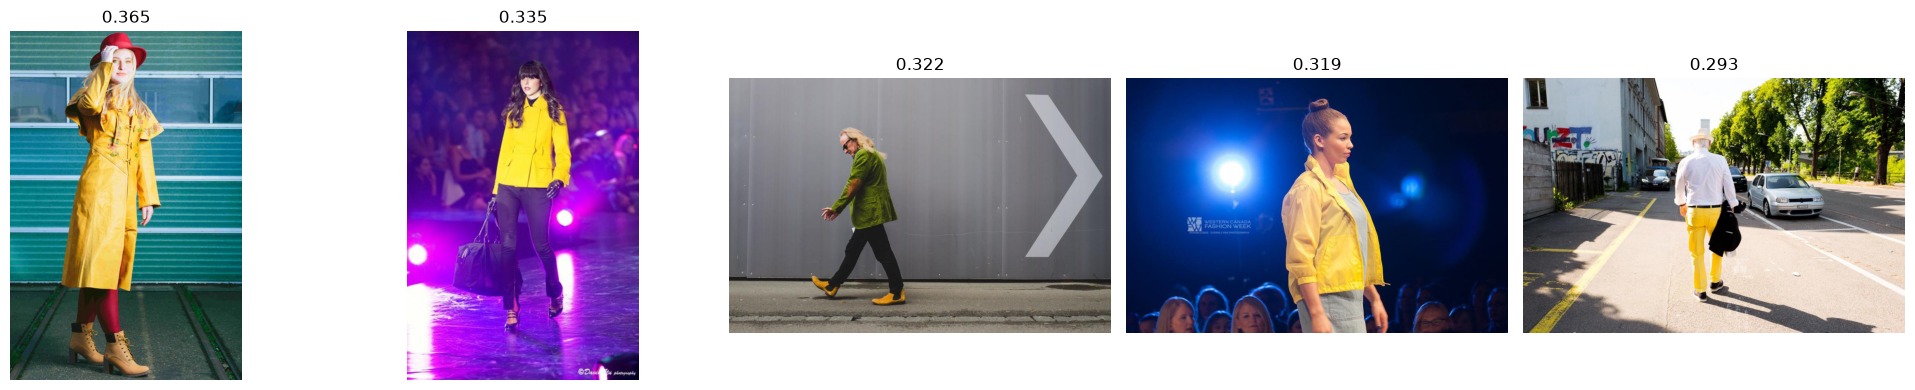

In [22]:
show_results(retrieve("A person in a bright yellow raincoat.", 5))

In [18]:
# queries = [
#     "dog",
#     "cat",
#     "blue shirt",
#     "person wearing glasses",
#     "mountain",
#     "white sneakers",
#     "red handbag",
#     "black dress",
#     "watch",
#     "car"
# ]

# for q in queries:
#     print("="*50)
#     print(q)
#     results = retrieve(q, k=5)
#     show_results(results)